In [75]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_67985/1788881870.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


### Parameters

In [76]:
k_max = 7
pars = {
    "eta"   : 0.5, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:3] = 1/3
pars["gamma"][0:3] = 1/3

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


### Build some simple simulations for comparison

In [77]:
timesteps = int(1e5)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [78]:
update_every = 100

R = np.zeros(shape = (timesteps // update_every, k_max), dtype = int)

# print(R.shape)

for cc in range(timesteps):
    e_ = H.sample_edge(eta, gamma, beta, True)
    eid = H.num_edges-1
    e_size = len(e_)    
    # update the size of r accordingly. it should always be max_size + 1
    # find all neighbors that have intersection with e_
    de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
    # count all the intersection sizes and add to r
    for nb in de:
        nb_size = len(nb)
        k = len(e_.intersection(nb))
        r[(e_size, nb_size, k)] += 1
        if nb_size != e_size:
            r[(nb_size, e_size, k)] += 1
        
    neighbor_sizes = [len(x) for x in de]
    nb_size_cnt = Counter(neighbor_sizes)
    for j, nj in edge_size_dict.items():
        # assert(nj >= nb_size_cnt[j])
        r[(j, e_size, 0)] += nj - nb_size_cnt[j]
        if j != e_size:
            r[(e_size, j, 0)] += nj - nb_size_cnt[j]

    if cc % update_every == 0:
        # print(cc)
        for k in range(k_max):
            R[cc//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
    edge_size_dict[e_size] += 1

In [79]:
R

array([[         2,          1,          0, ...,          0,          0,
                 0],
       [      4448,       2647,        444, ...,          7,          0,
                 0],
       [     21280,       7805,        982, ...,         28,          3,
                 0],
       ...,
       [5802990309,   23388980,     417341, ...,      18115,       2093,
                54],
       [5814948893,   23431442,     417985, ...,      18140,       2096,
                54],
       [5826935581,   23453770,     418245, ...,      18143,       2099,
                54]])

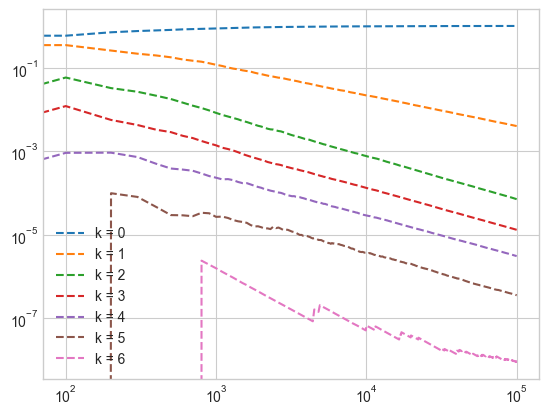

In [80]:
fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(np.arange(timesteps // update_every)*update_every, R[:, k], label = f"k = {k}", linestyle = "--")



ax.loglog()
ax.legend()

### Linear Algebra Approximation

A components
sparsity = 0.4898, nan = 0.0000
sparsity = 0.9445, nan = 0.0000
mask.shape =(1, 1, 7, 1, 1, 7)
sparsity = 0.5714, nan = 0.0000
A
sparsity = 0.9058, nan = 0.0000
B
sparsity = 0.7522, nan = 0.0000


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:62: RuntimeWarning: invalid value encountered in divide
  S2_kyljh = binom(H, K)*binom(L - H, Y - K)/binom(L, Y)


[Text(0.5, 1.0, 'Sparsity: 0.930')]

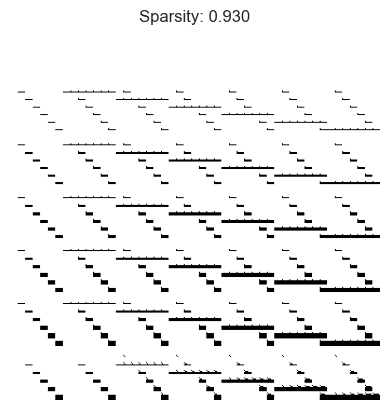

In [81]:
MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [9]:
EV = np.linalg.eig(M)

In [10]:
v = np.abs(EV[1][:,0])
T = m.vec_to_tensor(v, k_max)

q = T.sum(axis = (0, 1))
q = q / q.sum()
np.log(q)

q

array([5.46314643e-18, 3.76043937e-01, 3.42835695e-01, 2.02765045e-01,
       6.86606651e-02, 9.31315449e-03, 3.81504177e-04])

# Sample Asymptotics Plot

Eventually we want these curves to line up with the asymptotic lines, although obviously we are not there yet. 

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_67985/2630987069.py:21: RuntimeWarning: divide by zero encountered in divide
  ax.plot(M, q[k]*1/M, label = f"k = {k}", color = cmap(k/k_max))


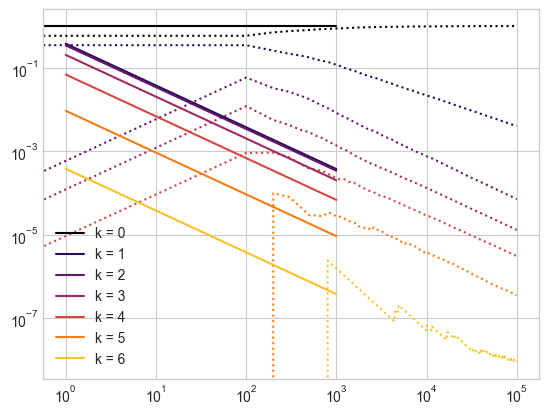

In [84]:

import matplotlib.cm as cm
cmap = cm.inferno

fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(np.arange(timesteps // update_every)*update_every, R[:, k], linestyle = ":", color = cmap(k/k_max))

q = T.sum(axis = (0, 1))
q = q / q.sum()
np.log(q)

q

M = np.arange(0, 1000) + 0

for k in range(0, len(q)): 
    if k == 0: 
        ax.plot(M, np.ones_like(M), label = f"k = {k}", color = cmap(k/k_max))
    else:    
        ax.plot(M, q[k]*1/M, label = f"k = {k}", color = cmap(k/k_max))

ax.loglog()
plt.legend()


In [83]:
np.log(q)

array([-39.74850678,  -0.97804929,  -1.07050397,  -1.59570739,
        -2.6785788 ,  -4.67632742,  -7.87138876])

## Diagnostics on B

Here, it's ok that these distributions don't fully normalize; that's a product of the truncation by `k_max`. With larger `k_max` we would see normalization everywhere. 

In [12]:
MC = m.MatrixConstructor(k_max, pars)

MC.B[:,:,2].sum(), MC.B[:,:,3].sum()

A components
sparsity = 0.4898, nan = 0.0000
sparsity = 0.9130, nan = 0.0000
sparsity = 0.7347, nan = 0.0000
A
sparsity = 0.8803, nan = 0.0000
B
sparsity = 0.7522, nan = 0.0000


(1.0, 0.9722222222222223)

## Diagnostics on A (second terms)


A components
sparsity = 0.6939, nan = 0.0000
sparsity = 0.9613, nan = 0.0000
mask.shape =(1, 1, 14, 1, 1, 14)
sparsity = 0.5357, nan = 0.0000
A
sparsity = 0.9362, nan = 0.0000
B
sparsity = 0.8415, nan = 0.0000


/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:62: RuntimeWarning: invalid value encountered in divide
  S2_kyljh = binom(H, K)*binom(L - H, Y - K)/binom(L, Y)
/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_67985/3762076345.py:22: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(A))


[Text(0.5, 0, 'intersection size k'),
 Text(0, 0.5, 'New edge size i'),
 Text(0.5, 1.0, 'probability mass = 1.00000')]

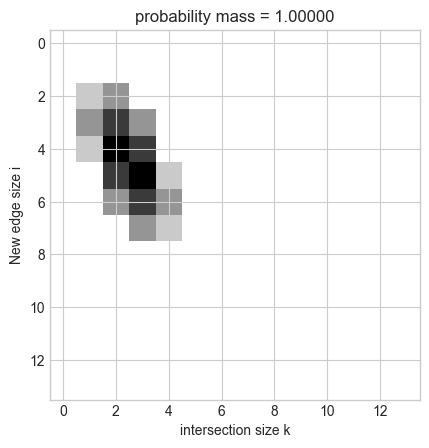

In [63]:
k_max = 14

pars = {
    "eta"   : 0.5, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:3] = 1/3
pars["gamma"][0:3] = 1/3

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


MC = m.MatrixConstructor(k_max, pars)

ell = 4
j   = 5
h   = 4

A = MC.A[:, :, ell, j, h]
plt.imshow(np.log(A))
plt.gca().set(xlabel = "intersection size k", ylabel = "New edge size i", title = f"probability mass = {A.sum():.5f}")




In [74]:
h = 6
MC.A[:,:,:,:,h].sum(axis = (0,1))


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0. 

Don't think the above is right. If $\ell = 3$, $j = 2$, and $h = 3$, then it should be p possible here to have $i = 2$ and $k = 1$; we would need to sample exactly one node from $|f \cap g|$ and then add a novel node. Similarly, it should be possible to have $i = 2$ and $k=2$ if we sample two nodes from $|f\cap g$ and add no novel nodes or nodes from the remainder of the hypergraph. 

So, this case needs to be made possible, and then we need to look for other sources of normalization violations. 

[1.         1.         1.         0.88888889 0.66666667 0.33333333
 0.11111111]


[Text(0.5, 0, 'extra nodes y'), Text(0, 0.5, 'edge size i')]

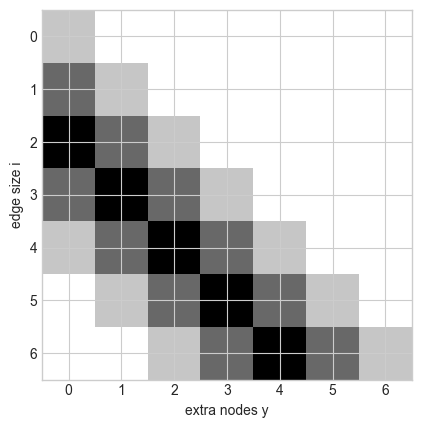

In [ ]:
x = 0

print(MC.S1_iy[:, x, x, x, x, :].sum(axis = 0))
plt.imshow(MC.S1_iy [:,x, x, x, x, :])
plt.gca().set(xlabel = "extra nodes y", ylabel = "edge size i")

S1_iy

## Optimization Experiments